In [1]:
import os ; import sys
cipath = "/home/joselado/Documents/programs/tranci" # address where the library is
sys.path.append(cipath+"/src")
import matplotlib.pyplot as plt

# Obtain Hund rules from exact calculation
This notebook shows how you can obtain the Hund's rules from exactly solving an interacting system

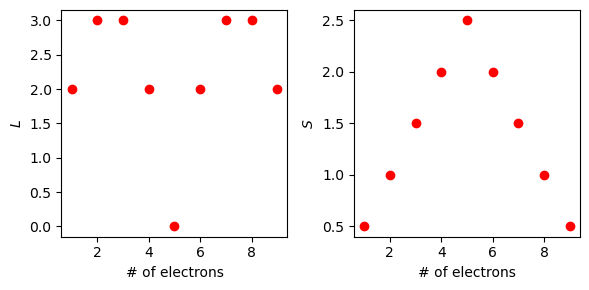

In [2]:
from tranci.atom import get_atom

fig = plt.figure(figsize=[6,3])

nes = range(1,10) # number of electrons
for ne in nes: # loop
    # generate an atom class for the system you want to compute
    Atom = get_atom(ne=ne) 
    # total Hamiltonian
    H = Atom.Operator["Coulomb"]
    M = Atom.get_manifolds(H) # get the manifolds object
    ops = [Atom.Operator["lz"],Atom.Operator["sz"]]
    no = len(ops) # number of operators
    for io in range(no): # loop over operators
        p = M.get_gs_projected_eigenvalues(ops[io])
        p = max(p)
        plt.subplot(1,no,io+1)
        plt.scatter(p*0 + ne,p,c="red")
        plt.xlabel("# of electrons")
        if io==0: plt.ylabel("$L$")
        if io==1: plt.ylabel("$S$")
plt.tight_layout()